In [ ]:
!pip install -q kagglehub

In [ ]:
!pip install tensorflow

In [ ]:
import kagglehub

kagglehub.login()

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "akansha03mulchandani/soyabean"
)

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'soyabean' dataset.
Dataset downloaded to:
/kaggle/input/soyabean


In [ ]:
print("Main Dataset Folder:")
print(dataset_path)

print("\nContents:")

for item in os.listdir(dataset_path):
    print(item)

Main Dataset Folder:
/kaggle/input/soyabean

Contents:
VOC2007


In [ ]:
for root, dirs, files in os.walk(dataset_path):

    print("\nFolder:", root)

    if dirs:
        print("Subfolders:", dirs[:10])

    if files:
        print("Sample files:", files[:5])


Folder: /kaggle/input/soyabean
Subfolders: ['VOC2007']

Folder: /kaggle/input/soyabean/VOC2007
Subfolders: ['ImageSets', 'JPEGImages', 'SegmentationClass']

Folder: /kaggle/input/soyabean/VOC2007/ImageSets
Subfolders: ['Segmentation']

Folder: /kaggle/input/soyabean/VOC2007/ImageSets/Segmentation
Sample files: ['val.txt', 'test.txt', 'train.txt', 'all.txt', 'class.txt']

Folder: /kaggle/input/soyabean/VOC2007/JPEGImages
Sample files: ['000304.jpg', '001506.jpg', '003113.jpg', '000705.jpg', '000908.jpg']

Folder: /kaggle/input/soyabean/VOC2007/SegmentationClass
Sample files: ['001703.png', '000419.png', '002712.png', '000920.png', '002011.png']


In [ ]:
image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


def count_images(folder):

    count = 0

    for root, dirs, files in os.walk(folder):

        for file in files:

            if file.lower().endswith(image_extensions):
                count += 1

    return count


# Find folders that contain images in subfolders

candidate_folders = []

for root, dirs, files in os.walk(dataset_path):

    image_subfolders = 0

    for d in dirs:

        subfolder = os.path.join(root, d)

        if count_images(subfolder) > 0:

            image_subfolders += 1

    if image_subfolders >= 2:

        candidate_folders.append(root)


if len(candidate_folders) == 0:

    print("Could not automatically find class folder.")

    print("Please check the dataset structure.")

else:

    data_dir = max(
        candidate_folders,
        key=count_images
    )

    print("Actual Image Dataset Path:")
    print(data_dir)

Actual Image Dataset Path:
/kaggle/input/soyabean/VOC2007


In [ ]:
# ==========================================
# 6. Check Classes
# ==========================================

class_names = sorted([
    folder
    for folder in os.listdir(data_dir)
    if os.path.isdir(
        os.path.join(data_dir, folder)
    )
])

print("Classes:")

for i, name in enumerate(class_names):

    print(i, ":", name)

print("\nNumber of Classes:", len(class_names))

Classes:
0 : ImageSets
1 : JPEGImages
2 : SegmentationClass

Number of Classes: 3


In [ ]:
for class_name in class_names:

    class_path = os.path.join(
        data_dir,
        class_name
    )

    count = count_images(class_path)

    print(
        class_name,
        ":",
        count,
        "images"
    )

ImageSets : 0 images
JPEGImages : 800 images
SegmentationClass : 800 images


In [ ]:
!pip install tensorflow

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import kagglehub

from tensorflow.keras.utils import image_dataset_from_directory

from tensorflow.keras.models import Model, Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Conv2D,
    MaxPooling2D,
    Flatten
)

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.21.0


In [ ]:
# ==========================================
# 2. CHECK GPU
# ==========================================

print("GPU available:", tf.config.list_physical_devices("GPU"))

GPU available: []


In [ ]:
dataset_path = kagglehub.dataset_download(
    "akansha03mulchandani/soyabean"
)

print("Dataset downloaded successfully!")
print("Dataset location:")
print(dataset_path)

Using Colab cache for faster access to the 'soyabean' dataset.
Dataset downloaded successfully!
Dataset location:
/kaggle/input/soyabean


In [ ]:
image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


def count_images(folder):

    count = 0

    for root, dirs, files in os.walk(folder):

        for file in files:

            if file.lower().endswith(image_extensions):

                count += 1

    return count


data_dir = None


for root, dirs, files in os.walk(dataset_path):

    # Count folders that contain images

    image_folders = 0

    for folder in dirs:

        folder_path = os.path.join(
            root,
            folder
        )

        if count_images(folder_path) > 0:

            image_folders += 1


    # At least two folders means
    # this is probably our class folder

    if image_folders >= 2:

        data_dir = root

        break


if data_dir is None:

    print("Dataset folder could not be found.")

else:

    print("Actual dataset folder:")
    print(data_dir)

Actual dataset folder:
/kaggle/input/soyabean/VOC2007


In [ ]:
class_names = sorted([

    folder

    for folder in os.listdir(data_dir)

    if os.path.isdir(
        os.path.join(data_dir, folder)
    )
])


print("Classes in Soyabean Dataset:")

for i, class_name in enumerate(class_names):

    print(i, "->", class_name)


num_classes = len(class_names)

print("\nNumber of classes:", num_classes)

Classes in Soyabean Dataset:
0 -> ImageSets
1 -> JPEGImages
2 -> SegmentationClass

Number of classes: 3


In [ ]:
print("Images in each class:\n")

for class_name in class_names:

    folder_path = os.path.join(
        data_dir,
        class_name
    )

    total_images = count_images(
        folder_path
    )

    print(
        class_name,
        ":",
        total_images,
        "images"
    )

Images in each class:

ImageSets : 0 images
JPEGImages : 800 images
SegmentationClass : 800 images


In [ ]:
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 1600 files belonging to 3 classes.
Using 1280 files for training.
Found 1600 files belonging to 3 classes.
Using 320 files for validation.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    AUTOTUNE
)

val_ds = val_ds.prefetch(
    AUTOTUNE
)

print("Dataset preparation completed!")

Dataset preparation completed!


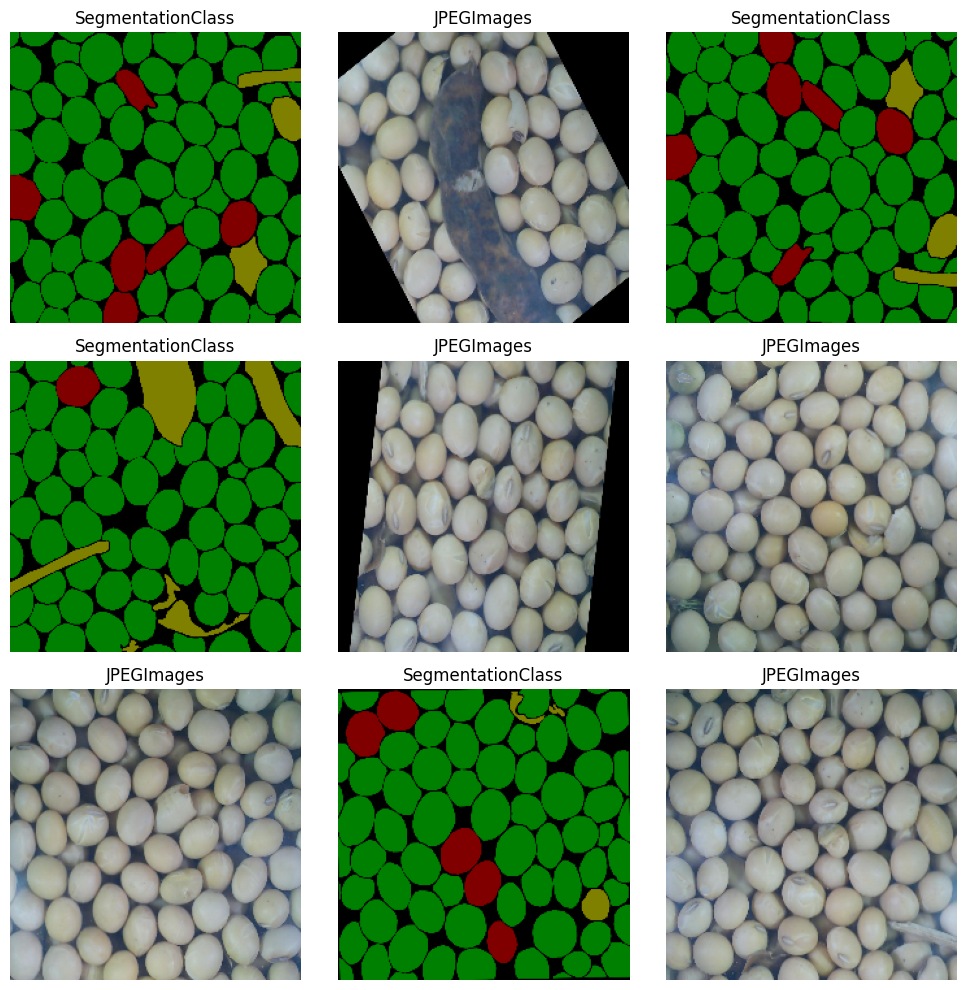

In [ ]:
plt.figure(figsize=(10, 10))


for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(
            3,
            3,
            i + 1
        )

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")


plt.tight_layout()

plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.1
    ),

    tf.keras.layers.RandomZoom(
        0.1
    )
])

In [ ]:
def create_transfer_model(
    base_model,
    model_name
):

    # Freeze the pretrained model

    base_model.trainable = False


    # Input image

    inputs = tf.keras.Input(
        shape=(224, 224, 3)
    )


    # Data augmentation

    x = data_augmentation(inputs)


    # Preprocessing

    if model_name == "VGG16":

        x = vgg_preprocess(x)

    elif model_name == "ResNet50":

        x = resnet_preprocess(x)

    # EfficientNet has its own preprocessing


    # Pretrained model

    x = base_model(
        x,
        training=False
    )


    # Reduce feature maps

    x = GlobalAveragePooling2D()(x)


    # New classification layer

    x = Dense(
        128,
        activation="relu"
    )(x)


    # Dropout helps reduce overfitting

    x = Dropout(
        0.5
    )(x)


    # Final output

    outputs = Dense(
        num_classes,
        activation="softmax"
    )(x)


    # Create complete model

    model = Model(
        inputs,
        outputs
    )


    # Compile model

    model.compile(

        optimizer="adam",

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )


    return model

In [ ]:
print("=" * 50)
print("Training VGG16")
print("=" * 50)


vgg_base = VGG16(

    weights="imagenet",

    include_top=False,

    input_shape=(224, 224, 3)
)


vgg_model = create_transfer_model(
    vgg_base,
    "VGG16"
)


history_vgg = vgg_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=1
)

Training VGG16
40/40 ━━━━━━━━━━━━━━━━━━━━ 306s 8s/step - accuracy: 0.9453 - loss: 0.2569 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


In [ ]:
# Evaluate VGG16

vgg_loss, vgg_accuracy = vgg_model.evaluate(
    val_ds,
    verbose=1
)


print(
    "\nVGG16 Accuracy:",
    vgg_accuracy
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 60s 6s/step - accuracy: 1.0000 - loss: 0.0000e+00

VGG16 Accuracy: 1.0


In [ ]:
print("=" * 50)
print("Training ResNet50")
print("=" * 50)


resnet_base = ResNet50(

    weights="imagenet",

    include_top=False,

    input_shape=(224, 224, 3)
)


resnet_model = create_transfer_model(
    resnet_base,
    "ResNet50"
)


history_resnet = resnet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=1
)

Training ResNet50
40/40 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.9820 - loss: 0.0489 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


In [ ]:
# Evaluate ResNet50

resnet_loss, resnet_accuracy = resnet_model.evaluate(
    val_ds,
    verbose=1
)


print(
    "\nResNet50 Accuracy:",
    resnet_accuracy
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00

ResNet50 Accuracy: 1.0


In [ ]:

print("=" * 50)
print("Training EfficientNetB0")
print("=" * 50)


efficient_base = EfficientNetB0(

    weights="imagenet",

    include_top=False,

    input_shape=(224, 224, 3)
)


efficient_model = create_transfer_model(

    efficient_base,

    "EfficientNetB0"
)


history_efficient = efficient_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=1
)

Training EfficientNetB0
40/40 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9711 - loss: 0.0782 - val_accuracy: 1.0000 - val_loss: 7.1488e-05


In [ ]:
# Evaluate EfficientNetB0

efficient_loss, efficient_accuracy = efficient_model.evaluate(
    val_ds,
    verbose=1
)


print(
    "\nEfficientNetB0 Accuracy:",
    efficient_accuracy
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 978ms/step - accuracy: 1.0000 - loss: 7.1488e-05

EfficientNetB0 Accuracy: 1.0


In [ ]:

print("=" * 50)
print("Training AlexNet")
print("=" * 50)


alexnet_model = Sequential([


    # Input

    tf.keras.layers.Input(
        shape=(224, 224, 3)
    ),


    # First convolution

    Conv2D(
        96,
        (11, 11),
        strides=4,
        activation="relu"
    ),


    MaxPooling2D(
        pool_size=(3, 3),
        strides=2
    ),


    # Second convolution

    Conv2D(
        256,
        (5, 5),
        padding="same",
        activation="relu"
    ),


    MaxPooling2D(
        pool_size=(3, 3),
        strides=2
    ),


    # Third convolution

    Conv2D(
        384,
        (3, 3),
        padding="same",
        activation="relu"
    ),


    # Fourth convolution

    Conv2D(
        384,
        (3, 3),
        padding="same",
        activation="relu"
    ),


    # Fifth convolution

    Conv2D(
        256,
        (3, 3),
        padding="same",
        activation="relu"
    ),


    MaxPooling2D(
        pool_size=(3, 3),
        strides=2
    ),


    # Convert feature maps to vector

    Flatten(),


    # Fully connected layer

    Dense(
        512,
        activation="relu"
    ),


    Dropout(0.5),


    # Second fully connected layer

    Dense(
        256,
        activation="relu"
    ),


    Dropout(0.5),


    # Output

    Dense(
        num_classes,
        activation="softmax"
    )
])


alexnet_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


history_alexnet = alexnet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=1
)

Training AlexNet
40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8758 - loss: 5.2630 - val_accuracy: 1.0000 - val_loss: 5.8599e-07


In [ ]:
# Evaluate AlexNet

alexnet_loss, alexnet_accuracy = alexnet_model.evaluate(
    val_ds,
    verbose=1
)


print(
    "\nAlexNet Accuracy:",
    alexnet_accuracy
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 401ms/step - accuracy: 1.0000 - loss: 5.8599e-07

AlexNet Accuracy: 1.0


In [ ]:

results = pd.DataFrame({

    "Model": [

        "AlexNet",

        "VGG16",

        "ResNet50",

        "EfficientNetB0"
    ],


    "Accuracy": [

        alexnet_accuracy,

        vgg_accuracy,

        resnet_accuracy,

        efficient_accuracy
    ]
})


print("\nModel Performance:")
print(results)


Model Performance:
            Model  Accuracy
0         AlexNet       1.0
1           VGG16       1.0
2        ResNet50       1.0
3  EfficientNetB0       1.0


In [ ]:

results = results.sort_values(
    by="Accuracy",
    ascending=False
)


print(results)

            Model  Accuracy
0         AlexNet       1.0
1           VGG16       1.0
2        ResNet50       1.0
3  EfficientNetB0       1.0


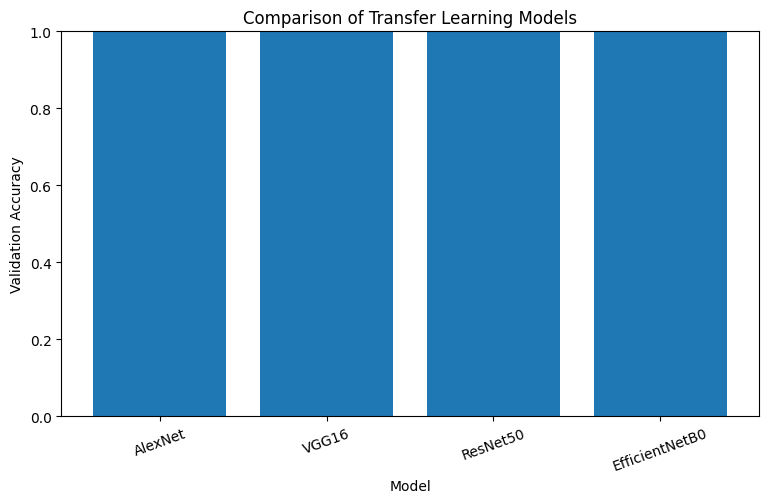

In [ ]:

plt.figure(figsize=(9, 5))
plt.bar(
    results["Model"],
    results["Accuracy"]
)


plt.xlabel("Model")
plt.ylabel("Validation Accuracy")

plt.title(
    "Comparison of Transfer Learning Models"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.show()

In [ ]:

best_model = results.iloc[0]
print("=" * 50)
print("BEST MODEL")
print("=" * 50)
print(
    "Model:",
    best_model["Model"]
)
print(
    "Accuracy:",
    round(
        best_model["Accuracy"],
        4
    )
)

BEST MODEL
Model: AlexNet
Accuracy: 1.0


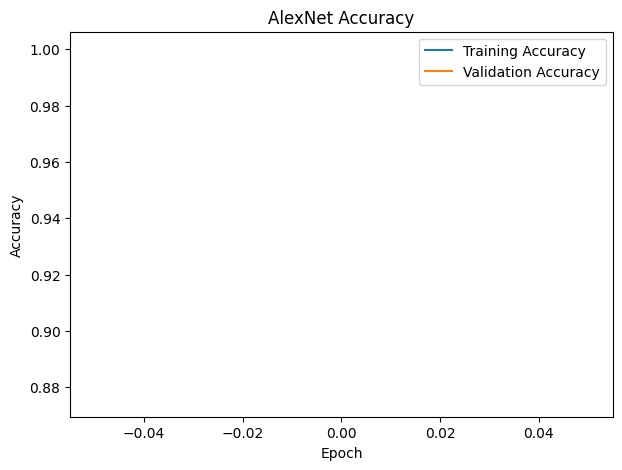

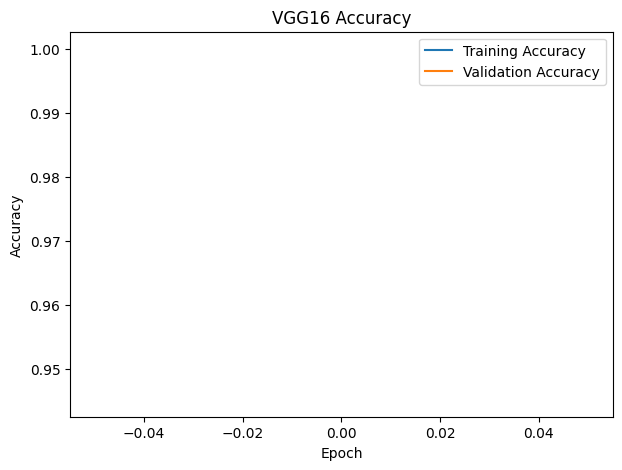

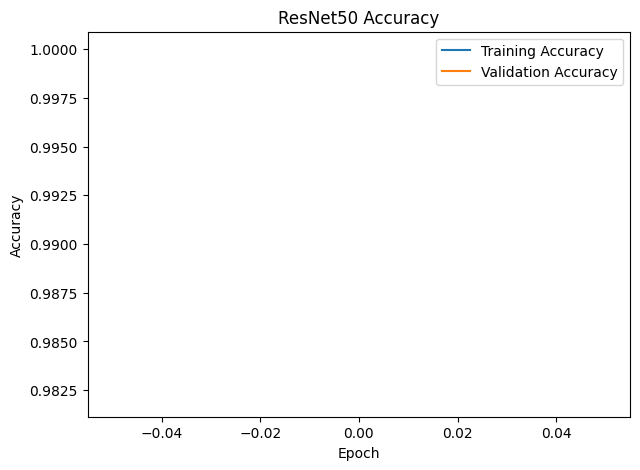

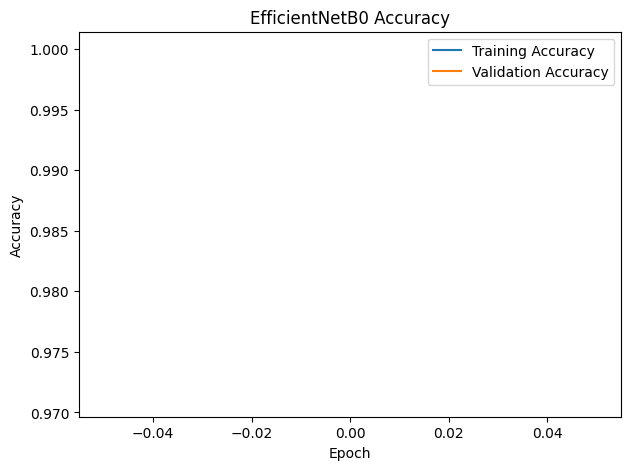

In [ ]:

histories = {
    "AlexNet": history_alexnet,
    "VGG16": history_vgg,
    "ResNet50": history_resnet,
    "EfficientNetB0": history_efficient
}


for model_name, history in histories.items():
    plt.figure(figsize=(7, 5))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )


    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )


    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")


    plt.title(
        model_name + " Accuracy"
    )


    plt.legend()

    plt.show()

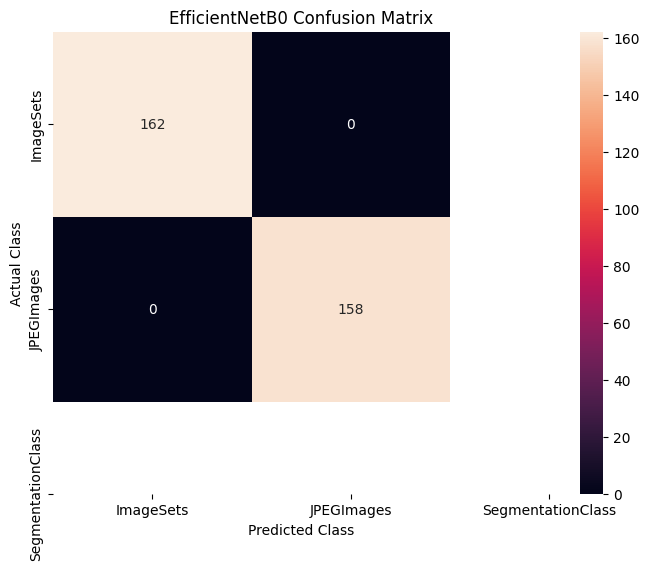

In [ ]:

best_tf_model = efficient_model
best_tf_model_name = "EfficientNetB0"
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = best_tf_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predictions
    )


# Create confusion matrix

cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(figsize=(8, 6))


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=class_names,

    yticklabels=class_names
)


plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")


plt.title(
    best_tf_model_name +
    " Confusion Matrix"
)


plt.show()

In [ ]:

print("\n")
print("=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)


print(
    "Transfer learning was implemented "
    "for Soyabean image classification."
)


print(
    "The models compared were:"
)


print(
    "1. AlexNet"
)

print(
    "2. VGG16"
)

print(
    "3. ResNet50"
)

print(
    "4. EfficientNetB0"
)


print("\nBest Model:")

print(
    best_model["Model"]
)


print(
    "Best Validation Accuracy:",
    round(
        best_model["Accuracy"],
        4
    )
)



FINAL CONCLUSION
Transfer learning was implemented for Soyabean image classification.
The models compared were:
1. AlexNet
2. VGG16
3. ResNet50
4. EfficientNetB0

Best Model:
AlexNet
Best Validation Accuracy: 1.0
